# Evaluación Sumativa 1. Análisis exploratorio e inferencial
## Dataset: Give Me Some Credit (riesgo crediticio)

MCDI501: Estadística Computacional para la Toma de Decisiones

Este cuaderno acompaña al informe técnico y contiene el código completo y reproducible. Sigue el mismo
orden del informe: preparación y calidad de los datos, análisis exploratorio, estimación de parámetros y
pruebas de hipótesis. La semilla del generador se fija en 42 para que los resultados se puedan reproducir.

## 0. Configuración y carga de datos

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os

SEED = 42
np.random.seed(SEED)

# Paleta y estilo propios del informe
INK   = '#2b2b2b'
TEAL  = '#2f6b76'
OCHRE = '#c0852f'
BRICK = '#a4503e'
STEM  = '#b9b0a2'
PANEL = '#f7f3ec'
GRIDC = '#ded6c8'
cmap_corr = LinearSegmentedColormap.from_list('teal_brick', [BRICK, '#efe7d9', TEAL])
cmap_corr.set_bad('white')

plt.rcParams.update({
    'figure.dpi':120, 'savefig.dpi':200, 'font.size':10, 'font.family':'serif',
    'figure.facecolor':'white', 'axes.facecolor':PANEL,
    'axes.edgecolor':'#9a9486', 'axes.linewidth':0.8,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.titlesize':11, 'axes.titlelocation':'left', 'axes.titlepad':8,
    'text.color':INK, 'axes.labelcolor':INK, 'xtick.color':INK, 'ytick.color':INK,
})

def grid_h(ax):
    # grilla horizontal tenue por detras de los datos
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRIDC, linewidth=0.7)
    ax.grid(axis='x', visible=False)

LOCAL  = 'cs-training.csv'
MIRROR = 'https://raw.githubusercontent.com/vivekkalyan/give-me-some-credit/master/cs-training.csv'
df = pd.read_csv(LOCAL, index_col=0) if os.path.exists(LOCAL) else pd.read_csv(MIRROR, index_col=0)
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Id,,,,,,,,,,,
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1. Preparación y calidad de los datos

Antes de cualquier análisis revisamos la estructura, los tipos de variable, los datos faltantes, los
duplicados y los valores que parecen errores de captura.

In [2]:
# Estructura y tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [3]:
n = len(df)
# Faltantes
faltantes = df.isna().sum()
print('Datos faltantes por variable:')
print(faltantes[faltantes > 0])
print()
# Duplicados
print('Filas duplicadas:', df.duplicated().sum())
# Valores fuera de rango o codigos especiales
print('Registros con edad = 0:', int((df['age'] == 0).sum()))
for c in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate',
          'NumberOfTime60-89DaysPastDueNotWorse']:
    print(f'Valores 96/98 en {c}:', int(df[c].isin([96, 98]).sum()))
# Asimetria de las variables con cola larga
print()
for c in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    print(f'Asimetria de {c}: {df[c].skew():.1f}  (max = {df[c].max():,.0f})')

Datos faltantes por variable:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Filas duplicadas: 609
Registros con edad = 0: 1
Valores 96/98 en NumberOfTime30-59DaysPastDueNotWorse: 269
Valores 96/98 en NumberOfTimes90DaysLate: 269
Valores 96/98 en NumberOfTime60-89DaysPastDueNotWorse: 269

Asimetria de RevolvingUtilizationOfUnsecuredLines: 97.6  (max = 50,708)
Asimetria de DebtRatio: 95.2  (max = 329,664)
Asimetria de MonthlyIncome: 114.0  (max = 3,008,750)


**Decisiones de tratamiento.** El ingreso mensual concentra cerca del 20% de los faltantes y el número
de dependientes algo menos del 3%. En esta fase trabajamos con los casos completos al estimar esas
variables y dejamos la imputación para el modelamiento. La edad con valor 0 (un registro) se descarta por
ser imposible. Los valores 96 y 98 en las variables de atrasos funcionan como códigos especiales y se
excluyen cuando se analizan esas columnas. Los valores extremos de utilización, ratio de deuda e ingreso
se conservan, porque para la estimación robusta del ingreso usamos la mediana como referencia y en los
gráficos recortamos la cola alta solo para que se aprecie la forma de la distribución.

Sobre las 609 filas duplicadas: se documentan y se conservan en esta fase descriptiva. Como los predictores
son de baja resolución (conteos y variables acotadas), filas idénticas pueden corresponder a solicitantes
distintos con el mismo perfil, de modo que su eliminación no es evidente y se difiere al modelamiento,
donde se evaluará su efecto sobre el desempeño.

## 2. Análisis exploratorio de datos

### 2.1 Estadística descriptiva

In [4]:
desc = df.drop(columns=['SeriousDlqin2yrs']).describe().T[['mean','50%','std','min','max']]
desc['skew'] = df.drop(columns=['SeriousDlqin2yrs']).skew()
desc.columns = ['Media','Mediana','Desv. est.','Mínimo','Máximo','Asimetría']
desc.round(2)

,Media,Mediana,Desv. est.,Mínimo,Máximo,Asimetría
RevolvingUtilizationOfUnsecuredLines,6.05,0.15,249.76,0.0,50708.0,97.63
age,52.30,52.00,14.77,0.0,109.0,0.19
NumberOfTime30-59DaysPastDueNotWorse,0.42,0.00,4.19,0.0,98.0,22.60
DebtRatio,353.01,0.37,2037.82,0.0,329664.0,95.16
MonthlyIncome,6670.22,5400.00,14384.67,0.0,3008750.0,114.04
NumberOfOpenCreditLinesAndLoans,8.45,8.00,5.15,0.0,58.0,1.22
NumberOfTimes90DaysLate,0.27,0.00,4.17,0.0,98.0,23.09
NumberRealEstateLoansOrLines,1.02,1.00,1.13,0.0,54.0,3.48
NumberOfTime60-89DaysPastDueNotWorse,0.24,0.00,4.16,0.0,98.0,23.33
NumberOfDependents,0.76,0.00,1.12,0.0,20.0,1.59


### 2.2 Figura 1. Variable objetivo y datos faltantes

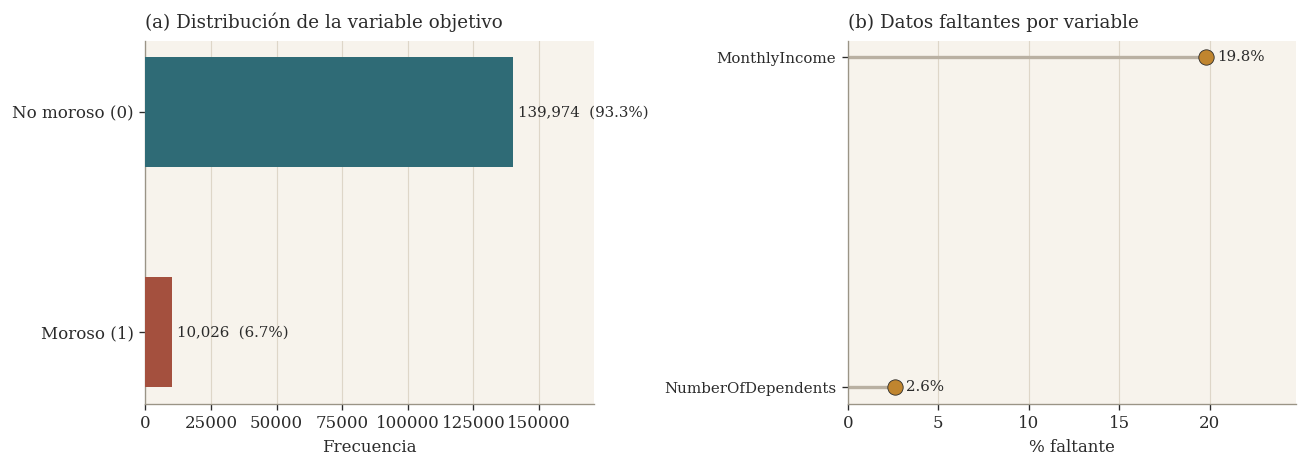

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

vc = df['SeriousDlqin2yrs'].value_counts().sort_index()
ax[0].barh(['No moroso (0)', 'Moroso (1)'], vc.values, color=[TEAL, BRICK], height=0.5, zorder=3)
for i, v in enumerate(vc.values):
    ax[0].text(v + vc.max()*0.015, i, f'{v:,}  ({v/n*100:.1f}%)', va='center', fontsize=9, color=INK)
ax[0].set_xlim(0, vc.max()*1.22); ax[0].invert_yaxis()
ax[0].set_xlabel('Frecuencia'); ax[0].set_title('(a) Distribución de la variable objetivo')
ax[0].set_axisbelow(True); ax[0].grid(axis='x', color=GRIDC, linewidth=0.7); ax[0].grid(axis='y', visible=False)

miss = (df.isna().mean()*100).sort_values(ascending=False); miss = miss[miss>0]
yy = range(len(miss))
ax[1].hlines(list(yy), 0, miss.values, color=STEM, lw=2.0, zorder=2)
ax[1].scatter(miss.values, list(yy), color=OCHRE, s=85, zorder=3, edgecolor=INK, linewidth=0.5)
for i, v in enumerate(miss.values):
    ax[1].text(v + miss.values.max()*0.03, i, f'{v:.1f}%', va='center', fontsize=9, color=INK)
ax[1].set_yticks(list(yy)); ax[1].set_yticklabels(miss.index, fontsize=9); ax[1].invert_yaxis()
ax[1].set_xlim(0, miss.values.max()*1.25); ax[1].set_xlabel('% faltante')
ax[1].set_title('(b) Datos faltantes por variable')
ax[1].set_axisbelow(True); ax[1].grid(axis='x', color=GRIDC, linewidth=0.7); ax[1].grid(axis='y', visible=False)

plt.tight_layout(); plt.savefig('fig_panorama.png', bbox_inches='tight'); plt.show()

### 2.3 Figura 2. Distribución de variables numéricas

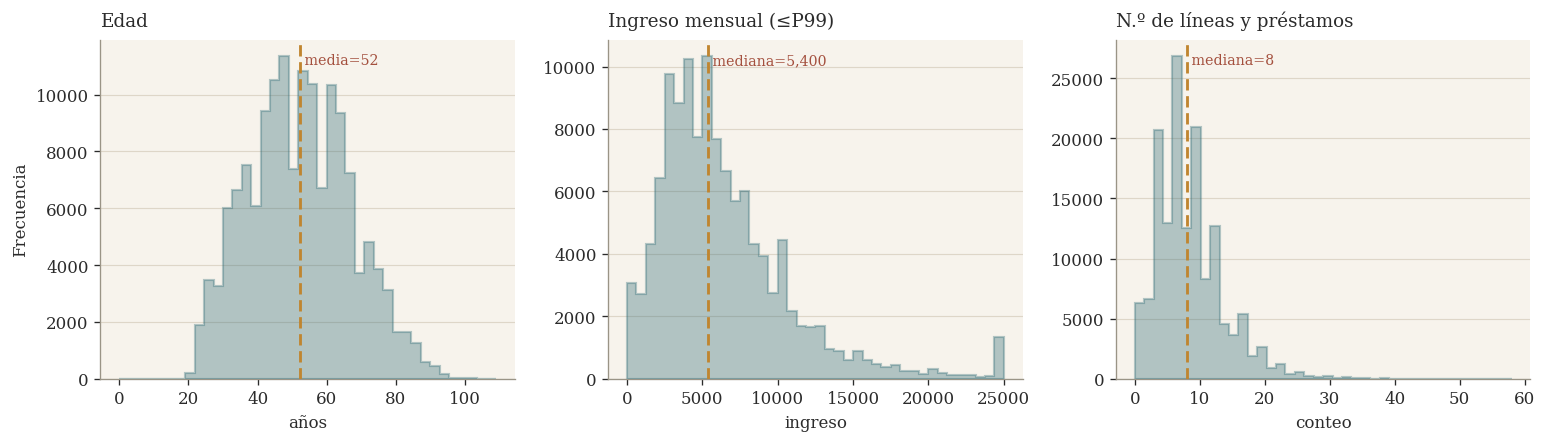

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

def hist_panel(a, data, titulo, xlab, ref, ref_lab):
    a.hist(data, bins=40, color=TEAL, alpha=0.35, edgecolor=TEAL, linewidth=1.3,
           histtype='stepfilled', zorder=3)
    a.axvline(ref, color=OCHRE, ls=(0,(4,2)), lw=1.7, zorder=4)
    a.text(ref, a.get_ylim()[1]*0.96, f' {ref_lab}={ref:,.0f}', color=BRICK, fontsize=8.5, va='top')
    a.set_title(titulo); a.set_xlabel(xlab); grid_h(a)

hist_panel(ax[0], df['age'], 'Edad', 'años', df['age'].mean(), 'media')
ax[0].set_ylabel('Frecuencia')
inc = df['MonthlyIncome'].dropna(); cap = inc.quantile(0.99)
hist_panel(ax[1], inc.clip(upper=cap), 'Ingreso mensual (≤P99)', 'ingreso', inc.median(), 'mediana')
hist_panel(ax[2], df['NumberOfOpenCreditLinesAndLoans'], 'N.º de líneas y préstamos', 'conteo',
           df['NumberOfOpenCreditLinesAndLoans'].median(), 'mediana')

plt.tight_layout(); plt.savefig('fig_distribuciones.png', bbox_inches='tight'); plt.show()

### 2.4 Figura 3. Matriz de correlaciones

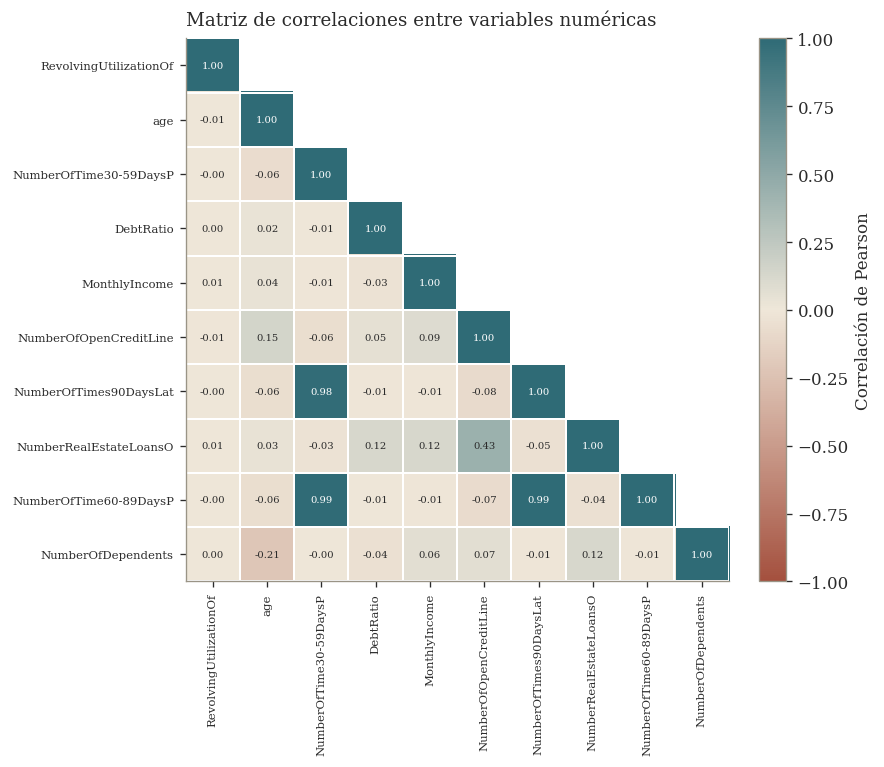

In [7]:
corr = df.drop(columns=['SeriousDlqin2yrs']).corr()
labels = [c[:22] for c in corr.columns]
M = np.ma.masked_array(corr.values, mask=np.triu(np.ones_like(corr.values, dtype=bool), k=1))

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.set_facecolor('white')
im = ax.imshow(M, cmap=cmap_corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
for i in range(len(corr)):
    for j in range(len(corr)):
        if j <= i:
            v = corr.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > 0.5 else INK)
ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2); ax.tick_params(which='minor', length=0)
cb = fig.colorbar(im, fraction=0.046, pad=0.04); cb.set_label('Correlación de Pearson')
ax.set_title('Matriz de correlaciones entre variables numéricas')
plt.tight_layout(); plt.savefig('fig_correlacion.png', bbox_inches='tight'); plt.show()

### 2.5 Análisis bivariado con variables derivadas

El conjunto no trae variables categóricas, así que construimos tres a partir de las numéricas: el tramo
etario, el cuartil de ingreso y un indicador de si el cliente registró algún atraso de 30 a 59 días. Con
ellas revisamos cómo cambia la tasa de morosidad.

In [8]:
# Variables categoricas derivadas
df['tramo_edad'] = pd.cut(df['age'], bins=[0,30,45,60,75,200],
                          labels=['<30','30-44','45-59','60-74','75+'], right=False)
df['cuartil_ingreso'] = pd.qcut(df['MonthlyIncome'], 4,
                                labels=['Q1 (bajo)','Q2','Q3','Q4 (alto)'])
_late = df['NumberOfTime30-59DaysPastDueNotWorse'].where(lambda s: s < 90)
df['atraso_30_59'] = np.where(_late >= 1, 'Con atraso', 'Sin atraso')
df.loc[_late.isna(), 'atraso_30_59'] = np.nan

gm = df['SeriousDlqin2yrs'].mean()*100
print(f'Tasa global de morosidad: {gm:.2f}%\n')
print('Morosidad por tramo etario (%):')
print((df.groupby('tramo_edad', observed=True)['SeriousDlqin2yrs'].mean()*100).round(2))
print('\nMorosidad por cuartil de ingreso (%):')
print((df.groupby('cuartil_ingreso', observed=True)['SeriousDlqin2yrs'].mean()*100).round(2))

Tasa global de morosidad: 6.68%

Morosidad por tramo etario (%):
tramo_edad
<30      11.73
30-44     9.49
45-59     7.04
60-74     3.44
75+       2.01
Name: SeriousDlqin2yrs, dtype: float64

Morosidad por cuartil de ingreso (%):
cuartil_ingreso
Q1 (bajo)    9.21
Q2           7.87
Q3           6.07
Q4 (alto)    4.62
Name: SeriousDlqin2yrs, dtype: float64


### 2.6 Figura 4. Morosidad según tramo etario y cuartil de ingreso

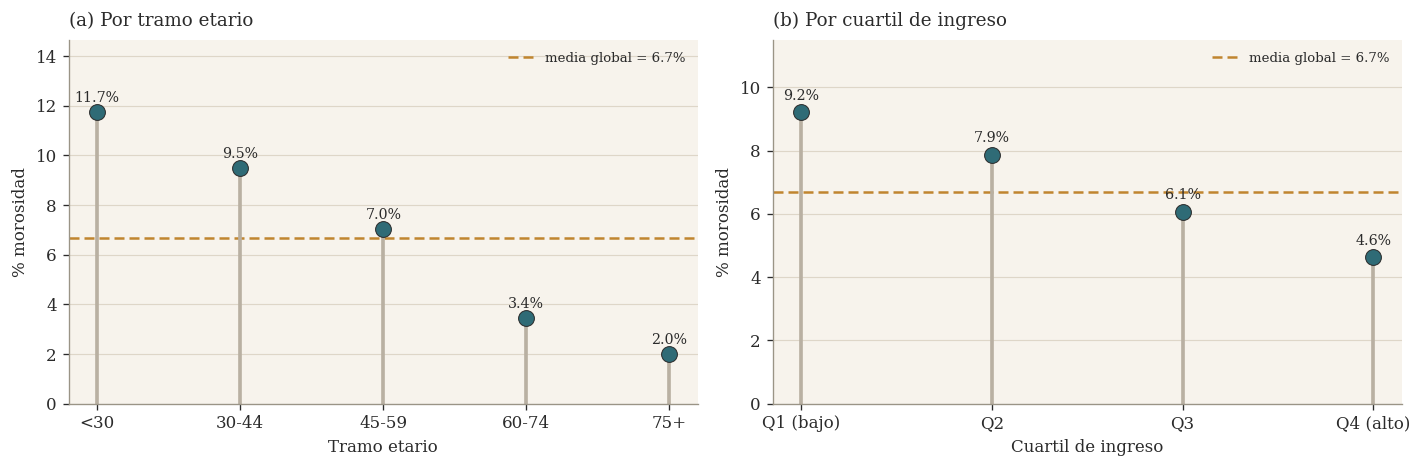

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

def lollipop_rate(a, serie_cat, titulo, xlab):
    t = df.groupby(serie_cat, observed=True)['SeriousDlqin2yrs'].mean()*100
    xx = range(len(t))
    a.axhline(gm, color=OCHRE, ls=(0,(4,2)), lw=1.5, zorder=2, label=f'media global = {gm:.1f}%')
    a.vlines(list(xx), 0, t.values, color=STEM, lw=2.2, zorder=2)
    a.scatter(list(xx), t.values, color=TEAL, s=90, zorder=3, edgecolor=INK, linewidth=0.6)
    for xi, yi in zip(xx, t.values):
        a.text(xi, yi+0.4, f'{yi:.1f}%', ha='center', fontsize=8.5, color=INK)
    a.set_xticks(list(xx)); a.set_xticklabels(t.index.astype(str))
    a.set_title(titulo); a.set_xlabel(xlab); a.set_ylabel('% morosidad')
    a.set_ylim(0, t.values.max()*1.25); grid_h(a); a.legend(fontsize=8, frameon=False)

lollipop_rate(ax[0], 'tramo_edad', '(a) Por tramo etario', 'Tramo etario')
lollipop_rate(ax[1], 'cuartil_ingreso', '(b) Por cuartil de ingreso', 'Cuartil de ingreso')
plt.tight_layout(); plt.savefig('fig_bivariado.png', bbox_inches='tight'); plt.show()

## 3. Estimación de parámetros

Estimación puntual e intervalos de confianza al 95% para tres variables numéricas (edad, ingreso mensual
y número de líneas y préstamos) y para la proporción de morosidad. Tanto para las medias como para la
proporción usamos el intervalo basado en la aproximación normal (método de Wald), que es el procedimiento
visto en clase y que el Teorema Central del Límite justifica dado el gran tamaño muestral.

Nota complementaria (no evaluada): para proporciones extremas o muestras pequeñas, el intervalo de Wilson
mejora la cobertura del de Wald; con el tamaño de muestra de este estudio ambos coinciden. El tema se
desarrolla en el apunte complementario del curso.

In [10]:
z = stats.norm.ppf(0.975)

def ic_media(x):
    x = pd.Series(x).dropna(); m = x.mean(); se = x.std(ddof=1)/np.sqrt(len(x))
    return m, m - z*se, m + z*se, len(x)

def ic_prop(k, n):
    p = k/n; se = np.sqrt(p*(1-p)/n)
    return p, p - z*se, p + z*se

for col, name in [('age','Edad (años)'), ('MonthlyIncome','Ingreso mensual'),
                  ('NumberOfOpenCreditLinesAndLoans','Líneas y préstamos')]:
    m, lo, hi, nn = ic_media(df[col])
    print(f'{name:20s}: estimación = {m:>10,.2f}   IC95% [{lo:,.2f}, {hi:,.2f}]   (n = {nn:,})')

p, lo, hi = ic_prop(df['SeriousDlqin2yrs'].sum(), n)
print(f'{"Proporción mora":20s}: estimación = {p:>10.4f}   IC95% [{lo:.4f}, {hi:.4f}]   (Wald)')

Edad (años)         : estimación =      52.30   IC95% [52.22, 52.37]   (n = 150,000)
Ingreso mensual     : estimación =   6,670.22   IC95% [6,588.92, 6,751.52]   (n = 120,269)
Líneas y préstamos  : estimación =       8.45   IC95% [8.43, 8.48]   (n = 150,000)
Proporción mora     : estimación =     0.0668   IC95% [0.0656, 0.0681]   (Wald)


## 4. Pruebas de hipótesis

### 4.1 Prueba 1. La edad media difiere entre morosos y no morosos (t de Welch)

Formulamos $H_0: \mu_{\text{moroso}} = \mu_{\text{no moroso}}$ contra $H_1: \mu_{\text{moroso}} \neq
\mu_{\text{no moroso}}$, con nivel de significancia 0,05. Revisamos los supuestos: independencia entre
grupos y forma aproximadamente simétrica. Como los grupos tienen tamaños muy dispares y desviaciones
estándar distintas, no asumimos varianzas iguales y usamos la prueba t de Welch, que estima el error
estándar por separado en cada grupo.

Nota complementaria (no evaluada): la igualdad de varianzas puede contrastarse formalmente con la prueba
de Levene, y la elección entre la prueba t estándar y la de Welch admite una discusión más fina. Ambos
temas se desarrollan en el apunte complementario del curso.

In [11]:
g1 = df.loc[df['SeriousDlqin2yrs']==1, 'age']
g0 = df.loc[df['SeriousDlqin2yrs']==0, 'age']

# Supuesto de forma: asimetria de cada grupo (cercana a 0 -> aproximadamente simetrica)
print('Verificación de supuestos')
print(f'  Grupo moroso   : n = {len(g1):,}  media = {g1.mean():.2f}  sd = {g1.std(ddof=1):.2f}  asimetría = {g1.skew():.2f}')
print(f'  Grupo no moroso: n = {len(g0):,}  media = {g0.mean():.2f}  sd = {g0.std(ddof=1):.2f}  asimetría = {g0.skew():.2f}')
# Las desviaciones difieren (12,9 vs 14,8) y los tamaños son muy dispares:
# no se asume igualdad de varianzas -> prueba t de Welch (equal_var=False)

# Prueba t de Welch
t, p = stats.ttest_ind(g1, g0, equal_var=False)
n1, n2 = len(g1), len(g0)
sp = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g0.var(ddof=1)) / (n1+n2-2))
d = (g1.mean() - g0.mean()) / sp
print(f'\nResultado: t = {t:.2f},  valor p = {p:.2e},  d de Cohen = {d:.3f}')
print('Decisión: p < 0,05, se rechaza H0. La diferencia de edad es significativa y de tamaño moderado.')

Verificación de supuestos
  Grupo moroso   : n = 10,026  media = 45.93  sd = 12.92  asimetría = 0.46
  Grupo no moroso: n = 139,974  media = 52.75  sd = 14.79  asimetría = 0.16

Resultado: t = -50.58,  valor p = 0.00e+00,  d de Cohen = -0.465
Decisión: p < 0,05, se rechaza H0. La diferencia de edad es significativa y de tamaño moderado.


### Figura 5. Distribución de la edad por grupo y morosidad por historial de atrasos

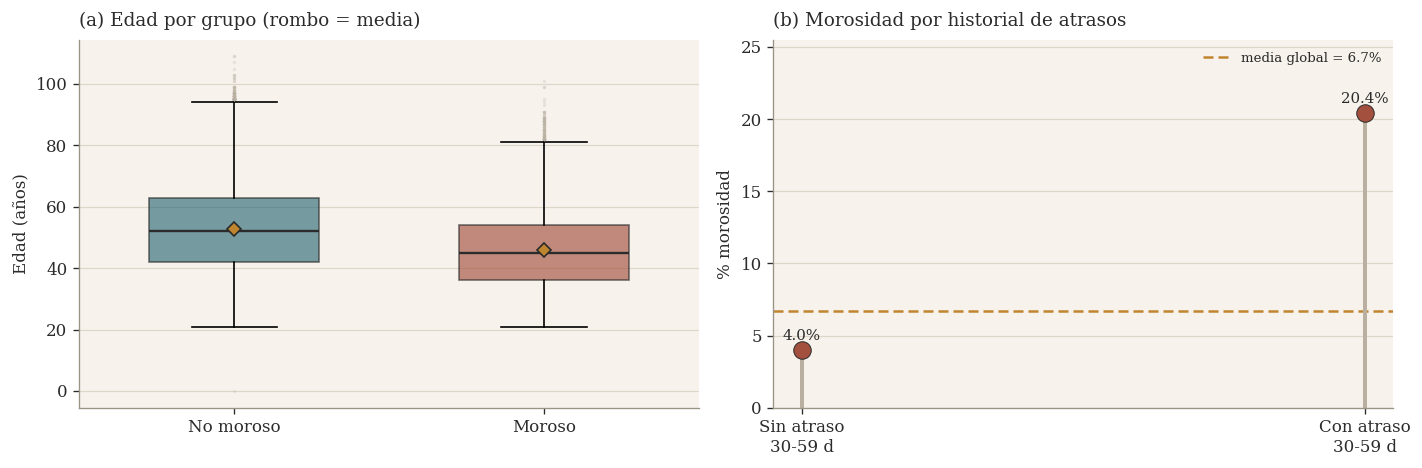

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# (a) boxplot de edad por clase
bp = ax[0].boxplot([g0, g1], tick_labels=['No moroso','Moroso'], patch_artist=True, widths=0.55,
                   showmeans=True,
                   meanprops=dict(marker='D', markerfacecolor=OCHRE, markeredgecolor=INK, markersize=6),
                   medianprops=dict(color=INK, linewidth=1.4),
                   flierprops=dict(marker='o', markersize=2, markerfacecolor=STEM, markeredgecolor='none', alpha=0.25))
for patch, col in zip(bp['boxes'], [TEAL, BRICK]):
    patch.set_facecolor(col); patch.set_alpha(0.65); patch.set_edgecolor(INK)
ax[0].set_ylabel('Edad (años)'); ax[0].set_title('(a) Edad por grupo (rombo = media)'); grid_h(ax[0])

# (b) morosidad con vs sin atraso 30-59 (lollipop)
tt = df.dropna(subset=['atraso_30_59']).groupby('atraso_30_59', observed=True)['SeriousDlqin2yrs'].mean()*100
tt = tt[['Sin atraso','Con atraso']]
xx = range(len(tt))
ax[1].axhline(gm, color=OCHRE, ls=(0,(4,2)), lw=1.5, zorder=2, label=f'media global = {gm:.1f}%')
ax[1].vlines(list(xx), 0, tt.values, color=STEM, lw=2.4, zorder=2)
ax[1].scatter(list(xx), tt.values, color=BRICK, s=110, zorder=3, edgecolor=INK, linewidth=0.6)
for xi, yi in zip(xx, tt.values):
    ax[1].text(xi, yi+0.7, f'{yi:.1f}%', ha='center', fontsize=9, color=INK)
ax[1].set_xticks(list(xx)); ax[1].set_xticklabels(['Sin atraso\n30-59 d','Con atraso\n30-59 d'])
ax[1].set_ylabel('% morosidad'); ax[1].set_title('(b) Morosidad por historial de atrasos')
ax[1].set_ylim(0, tt.values.max()*1.25); grid_h(ax[1]); ax[1].legend(fontsize=8, frameon=False)

plt.tight_layout(); plt.savefig('fig_hipotesis.png', bbox_inches='tight'); plt.show()

### 4.2 Prueba 2. El historial de atrasos se asocia con la morosidad (chi-cuadrado)

Formulamos $H_0$: el atraso de 30 a 59 días y la morosidad grave son independientes, contra $H_1$: están
asociados, con nivel 0,05. El supuesto de la prueba es que las frecuencias esperadas sean suficientes
(al menos 5 por celda).

In [13]:
tabla = pd.crosstab(df['atraso_30_59'], df['SeriousDlqin2yrs'])
print('Tabla de contingencia (filas: atraso; columnas: morosidad):')
print(tabla, '\n')

chi2, p, dof, esp = stats.chi2_contingency(tabla)
V = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))
print(f'Frecuencia esperada mínima: {esp.min():,.0f}  (supuesto cumplido)')
print(f'Chi-cuadrado = {chi2:,.1f},  gl = {dof},  valor p = {p:.2e},  V de Cramér = {V:.3f}')

# Tamaño del efecto practico: riesgo relativo y odds ratio
a, b = tabla.loc['Con atraso', 1], tabla.loc['Con atraso', 0]
c, d2 = tabla.loc['Sin atraso', 1], tabla.loc['Sin atraso', 0]
RR = (a/(a+b)) / (c/(c+d2)); OR = (a*d2)/(b*c)
print(f'Riesgo de morosidad con atraso = {a/(a+b)*100:.1f}%, sin atraso = {c/(c+d2)*100:.1f}%')
print(f'Riesgo relativo = {RR:.2f},  odds ratio = {OR:.2f}')
print('Decisión: p < 0,05, se rechaza H0. Existe asociación; el historial de atrasos multiplica el riesgo.')

Tabla de contingencia (filas: atraso; columnas: morosidad):
SeriousDlqin2yrs       0     1
atraso_30_59                  
Con atraso         18875  4838
Sin atraso        120977  5041 

Frecuencia esperada mínima: 1,565  (supuesto cumplido)
Chi-cuadrado = 8,709.9,  gl = 1,  valor p = 0.00e+00,  V de Cramér = 0.241
Riesgo de morosidad con atraso = 20.4%, sin atraso = 4.0%
Riesgo relativo = 5.10,  odds ratio = 6.15
Decisión: p < 0,05, se rechaza H0. Existe asociación; el historial de atrasos multiplica el riesgo.


## Síntesis de resultados

La variable objetivo está desbalanceada (6,68% de morosos). Las medias se estiman con intervalos
estrechos por el tamaño de la muestra. La edad difiere entre morosos y no morosos, con los clientes
jóvenes en mayor riesgo, y el historial de atrasos es la señal más fuerte: un atraso previo de 30 a 59
días multiplica por cinco el riesgo de morosidad. El ingreso muestra una relación monótona por cuartil,
aunque su correlación lineal con el objetivo es débil. Estos resultados alimentan las fases siguientes
del proyecto.